# Typst


![thumbnail](https://github.com/user-attachments/assets/c9877b35-a0f3-4bbd-8de3-4a849292d0b3)


Table of Contents

1. Basic Equation
2. Function arguments
3. Integration Example
4. Using Color in Equations
5. More symbols
6. Accessing SVG
7. Code Block Rendering

Link to extension: https://extensions.blender.org/add-ons/typst-importer/


In [45]:
import typst
typst.__version__

'0.15.0'

In [46]:
import sys
from pathlib import Path

from bl_ext.blender_org.typst_importer.notebook_utils import display_svg
from bl_ext.blender_org.typst_importer.typst_to_svg import typst_express

# The kernel runs inside Blender (not in the notebook folder), so add the docs helpers to sys.path
sys.path.append(str(Path.home() / "projects/bpy-gallery/docs/utils"))
from gallery_utils import fresh_scene, render_result

<class '_bpy_types.Collection'>


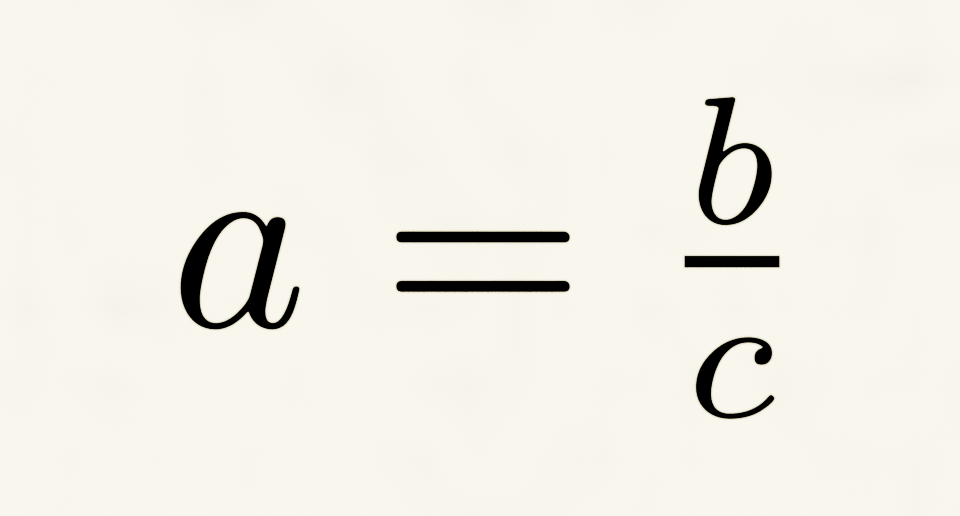

In [47]:
fresh_scene()

c = typst_express(
    "$ a = b/c$",
)
print(type(c))

render_result(collection=c)

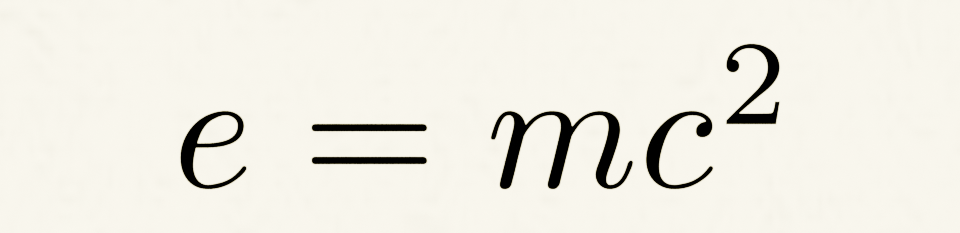

In [48]:
fresh_scene()

c = typst_express(
    "$ e = m c^2$",
    scale_factor=300,
    join_curves=True, 
    origin_to_char=False,
    name="Einstein's Equation"
)

render_result(collection=c)

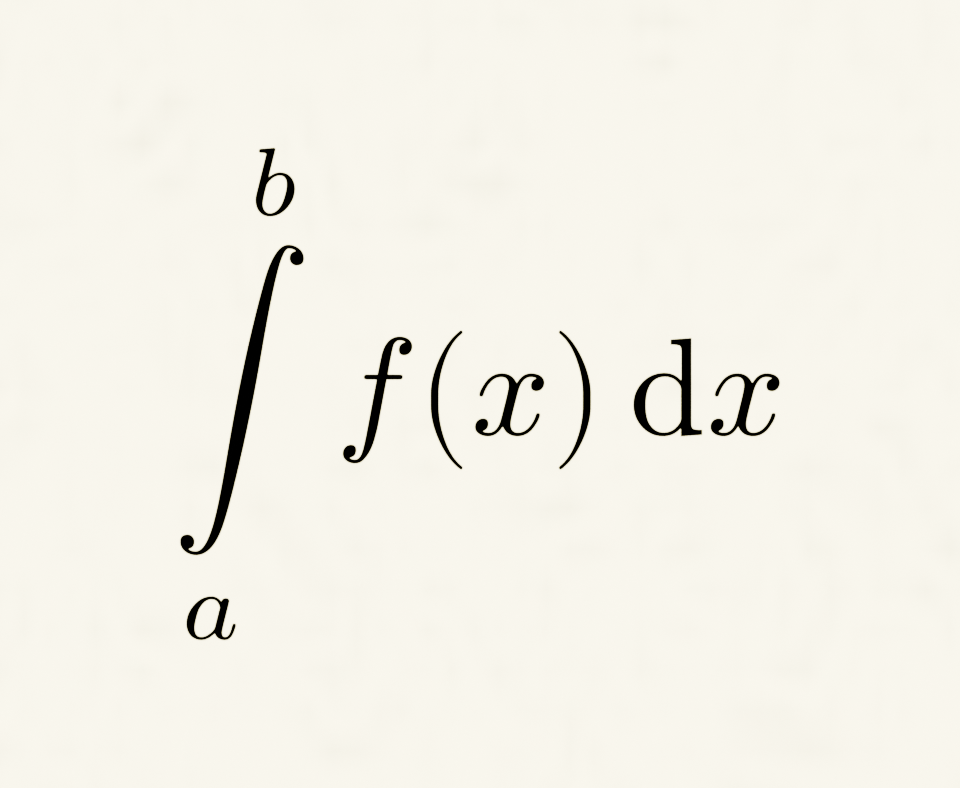

In [49]:
fresh_scene()

content = "$ limits(integral)_a^b f(x) dif x $" 
c = typst_express(content, join_curves=True, name="Integral")

render_result(collection=c)

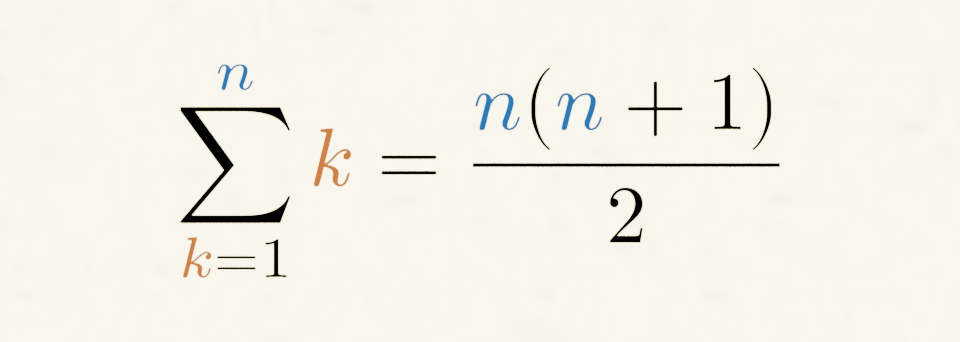

In [50]:
fresh_scene()

c = typst_express("""
#let korange() = text(fill: orange)[$k$]
#let nblue() = text(fill: blue)[$n$]
$ sum_(#korange() = 1)^#nblue() #korange() = (nblue()(nblue()+1)) / 2 $  
""")

render_result(collection=c, width="600pt")

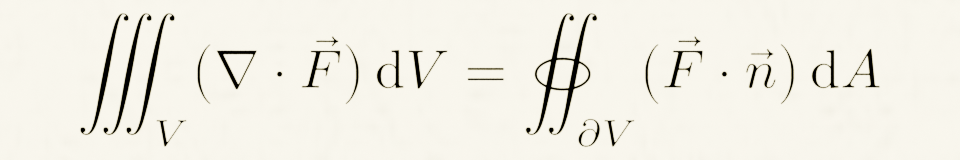

In [51]:
fresh_scene()

content = """
#set math.lr(size: 80%)
$ integral.triple _V (nabla dot accent(F, arrow)) dif V = integral.surf_(partial V)  (accent(F, arrow) dot accent(n, arrow)) dif A $
"""
c = typst_express(content)
render_result(collection=c , padding_factor=-0.4, width="1200pt")

In [52]:
print(f"...{c.processed_svg[490:550]}...")
display_svg(c.processed_svg, width="400pt")

...-7 -12.85c -1 0 -1.85 0.25 -2.55 0.8c 1.45 0.25 2.15 1.1 2.1...


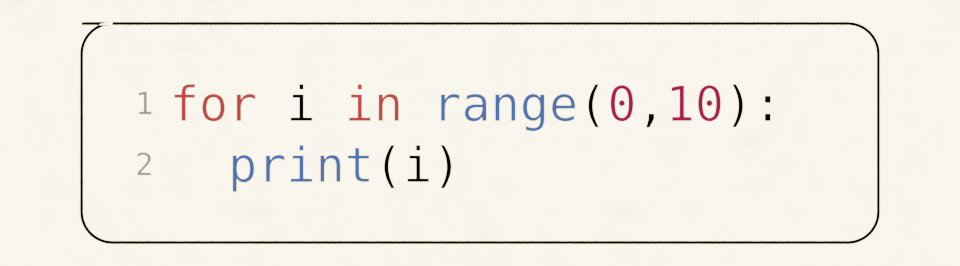

In [53]:
fresh_scene()

c = typst_express("""
#set page(width: 550pt, height: auto, margin: 1cm, fill: none)

#import "@preview/codelst:2.0.2": sourcecode
#import "@preview/tablex:0.0.9": tablex
#let sourcecode = sourcecode.with(frame: (code) => block(
  radius: 20pt,
  stroke: 2pt + luma(0),
  inset: 30pt,
  text(size: 30pt, code)
))

#sourcecode[```python
for i in range(0,10):
  print(i)
```]
""")

render_result(collection=c, padding_factor=-0.4, width="900pt")

In [54]:
print(f"...{c.processed_svg[490:550]}...")
display_svg(c.processed_svg, width="400pt")
# TODO TOP LEFT SVG render issue comes from the way I process svgs that come from Typst 0.14.1. Needs to be investigated if I find the time.

...85 1.0 L 31.25183317270539 1.0 L 32.477016489975924 1.0 L 33...


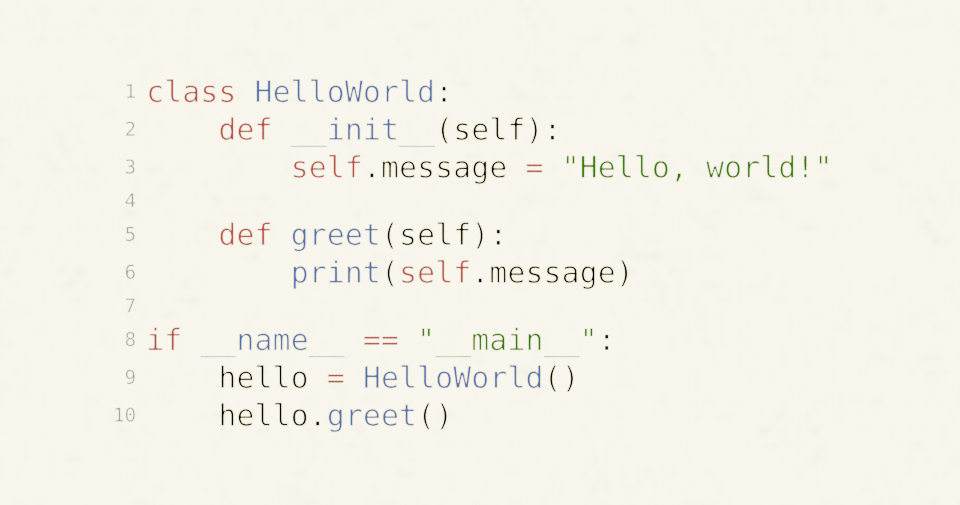

In [55]:
fresh_scene()

content = """
#set page(width: 800pt, height: auto, margin: 0cm, fill: none)

#import "@preview/codelst:2.0.2": sourcecode
#import "@preview/tablex:0.0.8": tablex

#let sourcecode = sourcecode.with(frame: (code) => block(
  radius: 5pt,
  stroke: 0pt + luma(0),
  inset: 30pt,
  text(size: 30pt, code)
))

#sourcecode[```python

class HelloWorld:
    def __init__(self):
        self.message = "Hello, world!"

    def greet(self):
        print(self.message)

if __name__ == "__main__":
    hello = HelloWorld()
    hello.greet()
```]
"""
c = typst_express(content)

render_result(collection=c , padding_factor=-0.4, width="800pt")

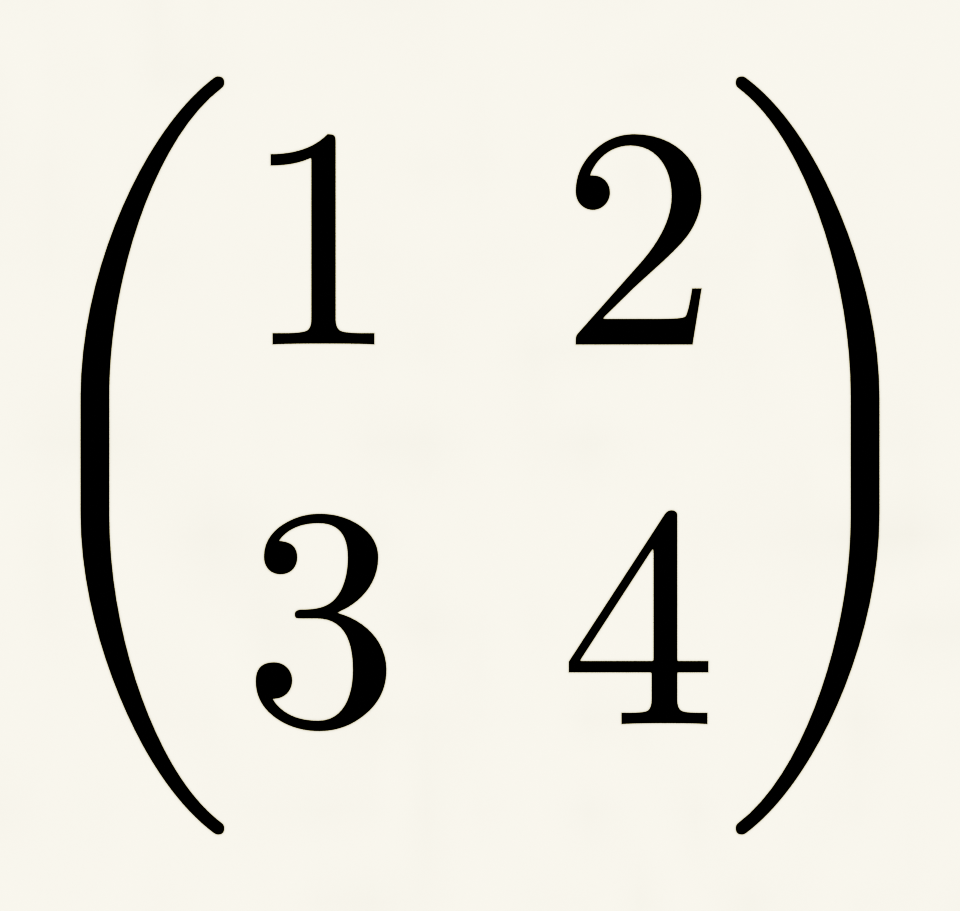

In [56]:
fresh_scene()

content = """
#set math.lr(size: 80%)
$ mat(1, 2; 3, 4) $"""
c = typst_express(content)

render_result(collection=c , padding_factor=-0.4, width="200pt")

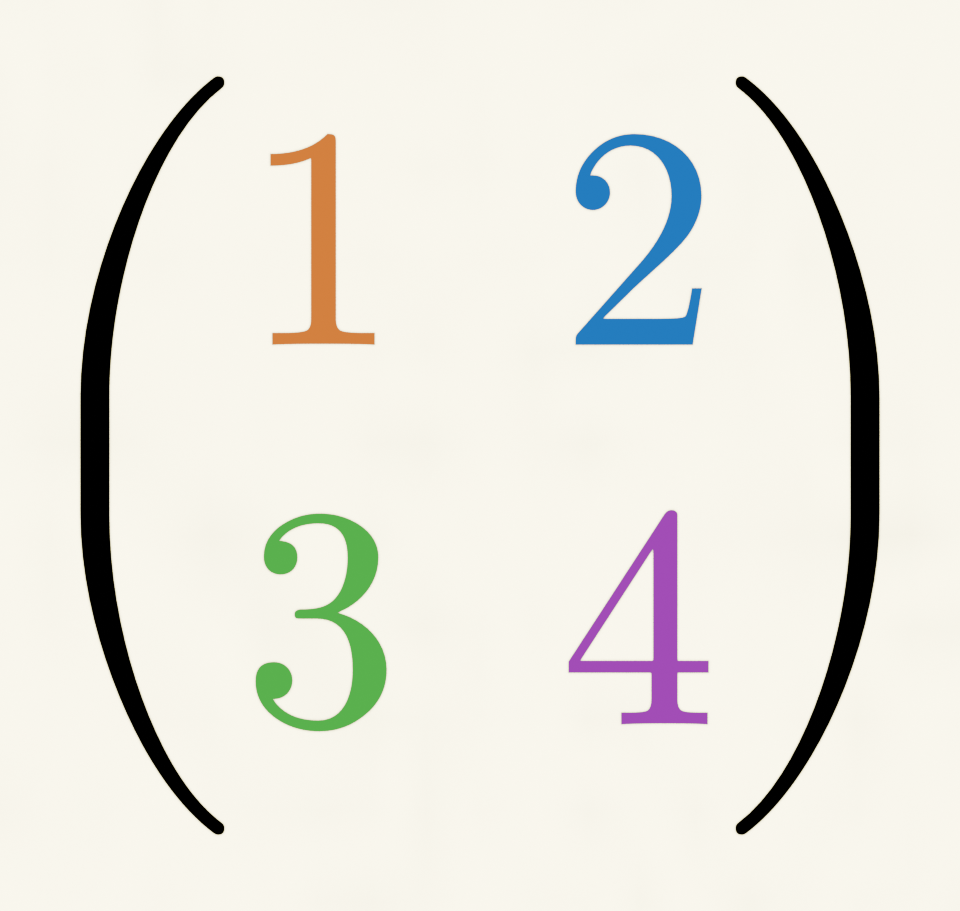

In [57]:
fresh_scene()

content = """
$ 
mat(
  #text(fill: orange)[1] , #text(fill: blue)[2] ;
  #text(fill: green)[3]  , #text(fill: purple)[4]
)
$
"""
c = typst_express(content)

render_result(collection=c , padding_factor=-0.4, width="200pt")

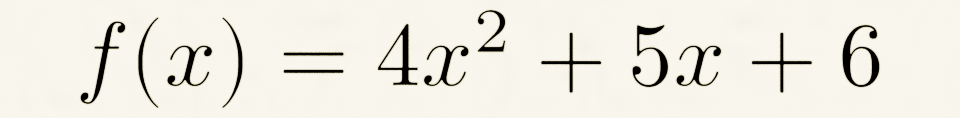

In [58]:
fresh_scene()

content = """
$ f(x) = 4x^2 + 5x + 6 $
"""
c = typst_express(content)

render_result(collection=c , padding_factor=-0.4, width="200pt")

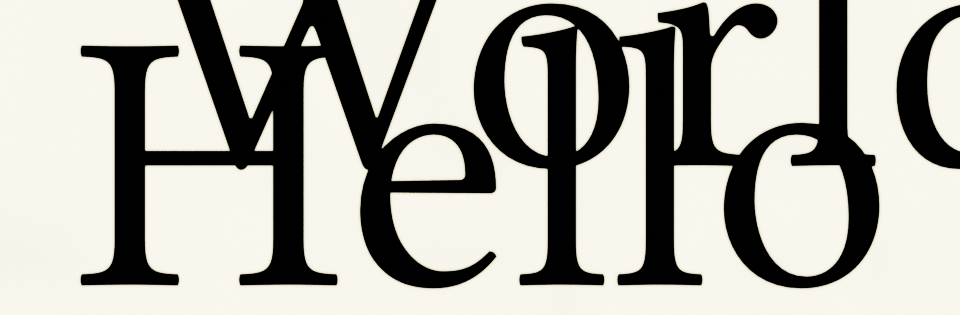

In [59]:
fresh_scene()

eq1 = """
Hello
"""

eq2 = """
World
"""

c1 = typst_express(
    eq1,
    origin_to_char=True,
    name="Term1",
    position=(0, 0, 0),  # Place at origin
)

c2 = typst_express(
    eq2,
    origin_to_char=True,
    name="Term2",
    position=(0.1, 0.2, 0),  # Place 2 units to the right
)

render_result(collection=c1, padding_factor=-0.4, width="200pt")

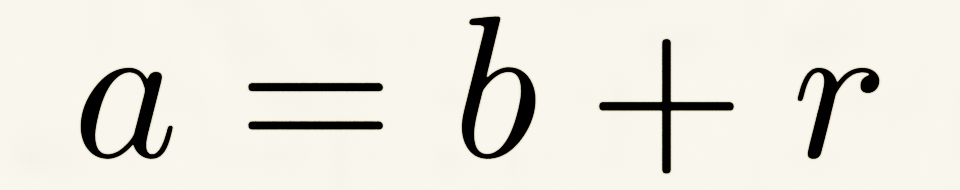

In [60]:
fresh_scene()

eq = """
#set text(black)
$ a = b + r $
"""
c = typst_express( eq, origin_to_char=True, name="Term1")
render_result(collection=c , padding_factor=-0.4, width="200pt")

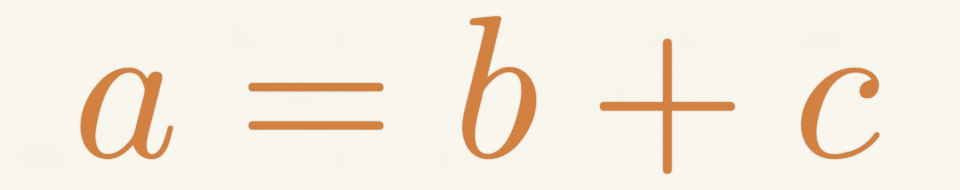

In [61]:
fresh_scene()

eq = """
#set text(orange)
$ a = b + c $
"""
c = typst_express( eq, origin_to_char=True, name="Term2")
render_result(collection=c, padding_factor=-0.4, width="200pt")

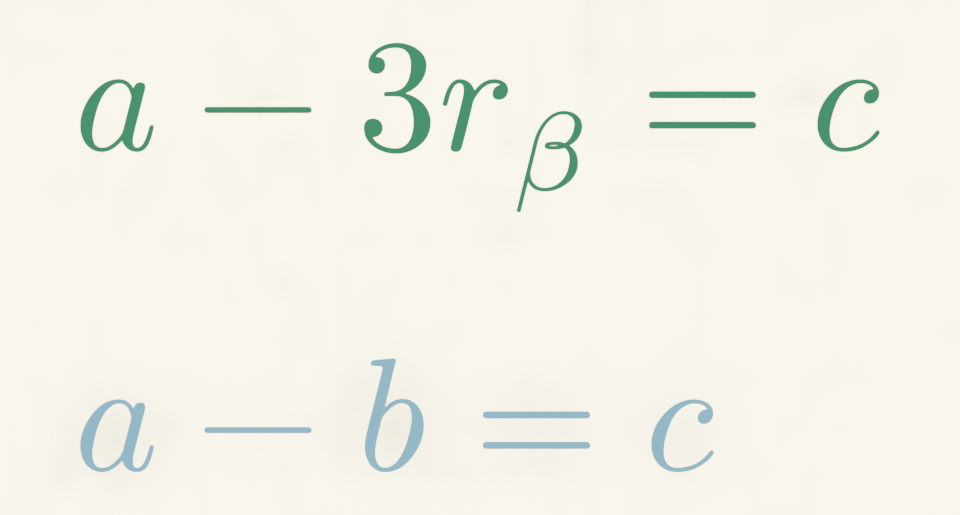

In [62]:
fresh_scene()

def eq(equation: str, name: str, color: str, position=(0, 0, 0)):

    typst_code = f"""
    #set text({color})
    $ {equation} $
    """
    collection = typst_express(
        typst_code,
        origin_to_char=True,
        convert_to_mesh=False,
        name=name,
        position=position
    )

    return collection

c1 = eq("a -b = c", "Start", "aqua", (0, -5, 0.5))
c2 = eq("a - 3 r_(beta) = c", "End", "olive", (0, -4, 0));

render_result(collection=[c1, c2] , padding_factor=-0.4, width="200pt")

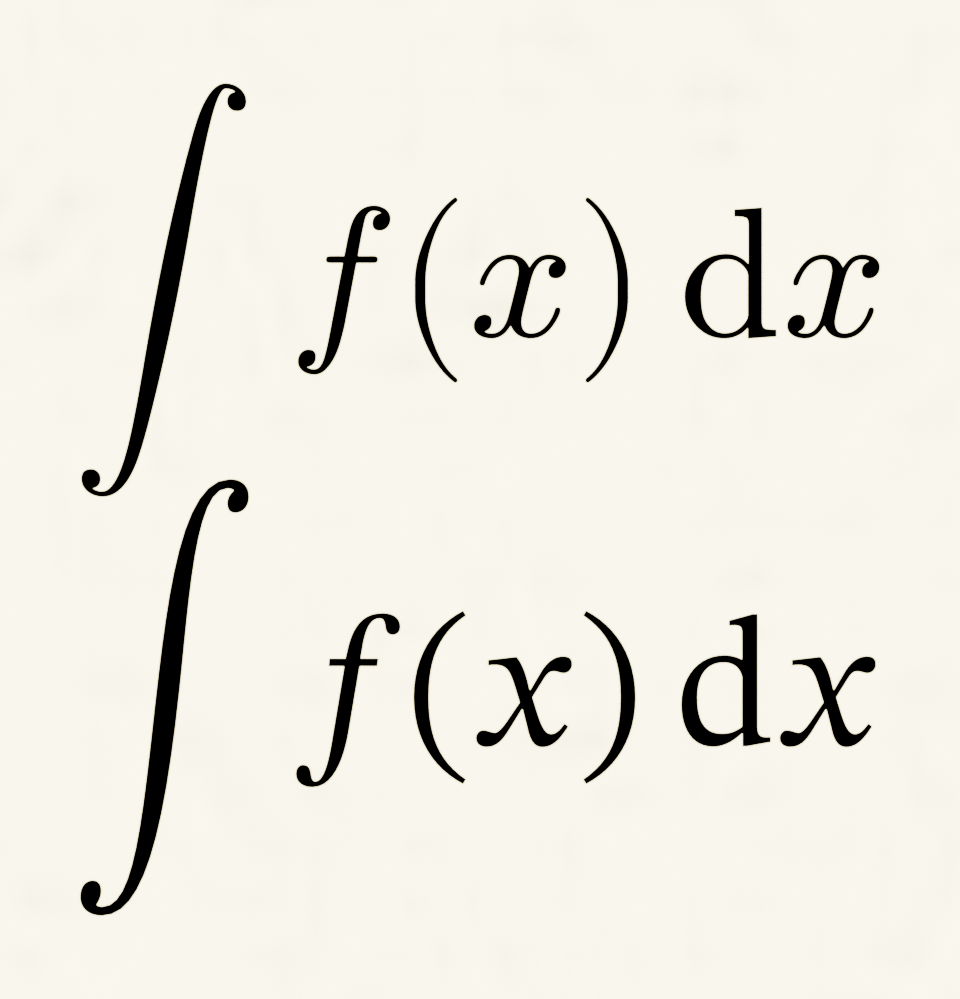

In [63]:
fresh_scene()

content = """
$ integral f(x) dif x $
"""
c1 = typst_express(content, origin_to_char=True, position=(0, 1.4, 0), name="A1")

content = """
#show math.equation: set text(font: "STIX Two Math")
$ integral f(x) dif x $
"""
c2 = typst_express(content, origin_to_char=True, position=(0, 0, 0), name="A2")

render_result(collection=[c1, c2] , padding_factor=-0.4, width="200pt")

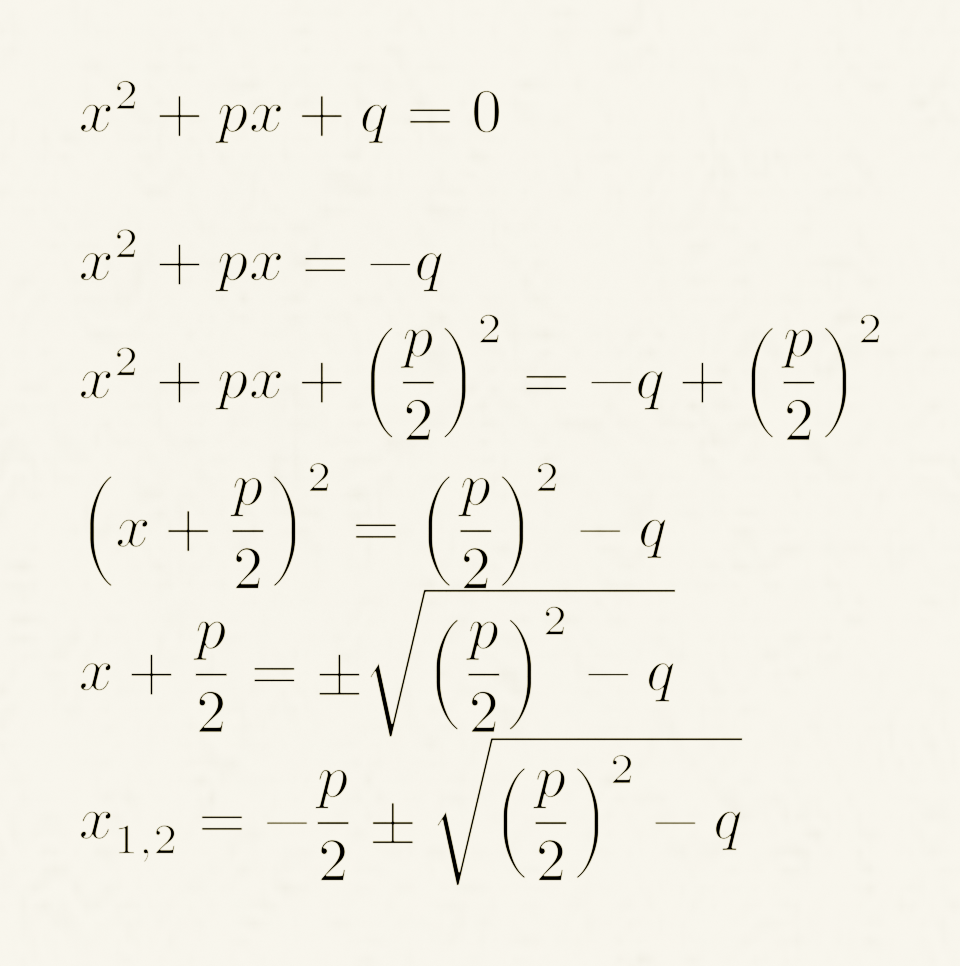

In [64]:
fresh_scene()

# General quadratic equation
c1 = typst_express("$ x^2 + p x + q = 0 $", origin_to_char=True, position=(0, 0, 10), name="Step1")

# Step 1: Complete the square
c2 = typst_express("$ x^2 + p x = -q $", origin_to_char=True, position=(0, -1.5, 9), name="Step2")

# Step 2: Add and subtract (p/2)^2 on the left side
c3 = typst_express("$ x^2 + p x + (p/2)^2 = -q + (p/2)^2 $", origin_to_char=True, position=(0, -3, 8), name="Step3")

# Step 3: Rewrite as squared binomial
c4 = typst_express("$ (x + p/2)^2 = (p/2)^2 - q $", origin_to_char=True, position=(0, -4.5, 7), name="Step4")

# Step 4: Square root both sides
c5 = typst_express("$ x + p/2 = plus.minus sqrt((p/2)^2 - q) $", origin_to_char=True, position=(0, -6, 6), name="Step5")

# Step 5: Solve explicitly for x
c6 = typst_express("$ x_(1,2) = -p/2 plus.minus sqrt((p/2)^2 - q) $", origin_to_char=True, position=(0, -7.5, 5), name="Step6")

# Render all steps
render_result(collection=[c1, c2, c3, c4, c5, c6], padding_factor=-0.4, width="600pt")

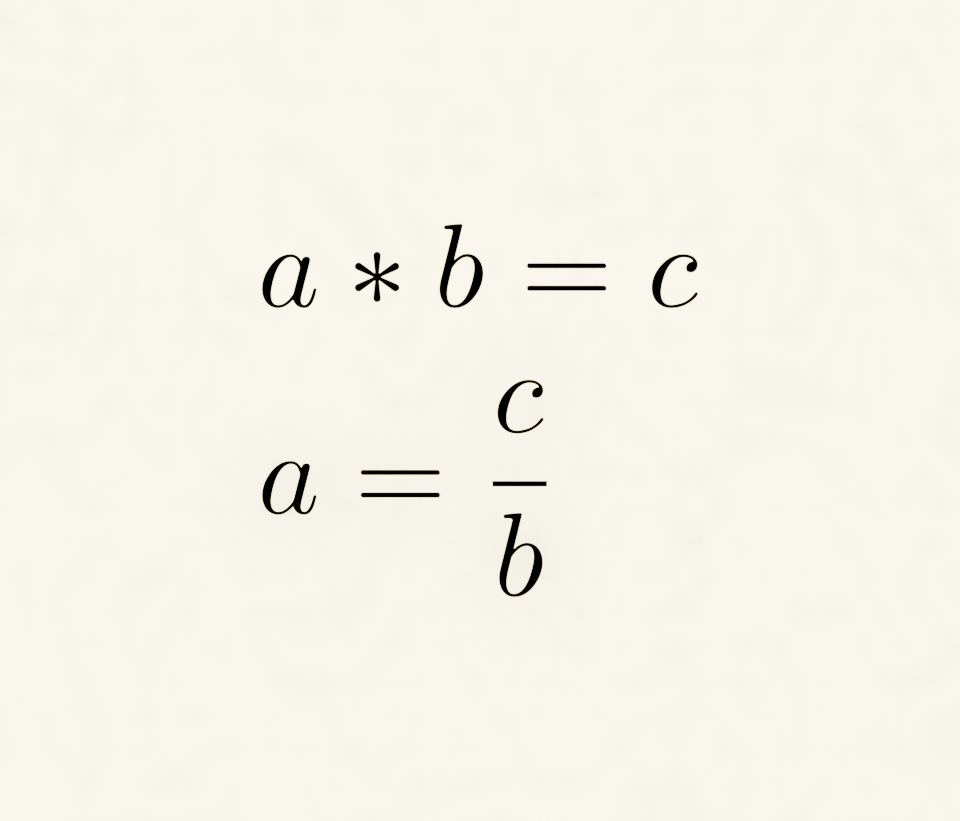

In [73]:
fresh_scene()

content = "$ a * b = c $"
c1 = typst_express(content, origin_to_char=True, position=(0, 0, 0), name="A1")

content = "$ a  = c / b  $"
c2 = typst_express(content, origin_to_char=True, position=(0, -1.5, 0.7), name="A2")

render_result(collection=[c1, c2], padding_factor= 0.1 , width="200pt")